# Posterior predictive plot gallery

A compact tour of `plot_predictive`'s renderings and uncertainty displays,
one option per section. For the full plotting API, see the
[Plotting tutorial](plotting.ipynb).

For demonstration purposes we inject a pre-computed trace with posterior
predictive samples into the model, so this notebook runs in seconds without
sampling. In practice you would obtain the trace from `model.sample()`.

In [1]:
from pathlib import Path

import arviz as az
import pandas as pd

import hssm

%config InlineBackend.figure_format = 'retina'

fixtures = Path("../../tests/fixtures")
cav_data = pd.read_csv(fixtures / "cavanagh_theta_test.csv", index_col=None)
model = hssm.HSSM(
    data=cav_data,
    include=[{"name": "v", "formula": "v ~ theta + (1|participant_id)"}],
)
model._inference_obj = az.from_netcdf(fixtures / "cavanagh_idata.nc")

Model initialized successfully.


## The default: graded uncertainty bands

Graded **50% + 94% equal-tailed bands** around the predictive mean, step
histograms, legend, despined axes, x-range fit to the data, signed-RT axis
annotation.

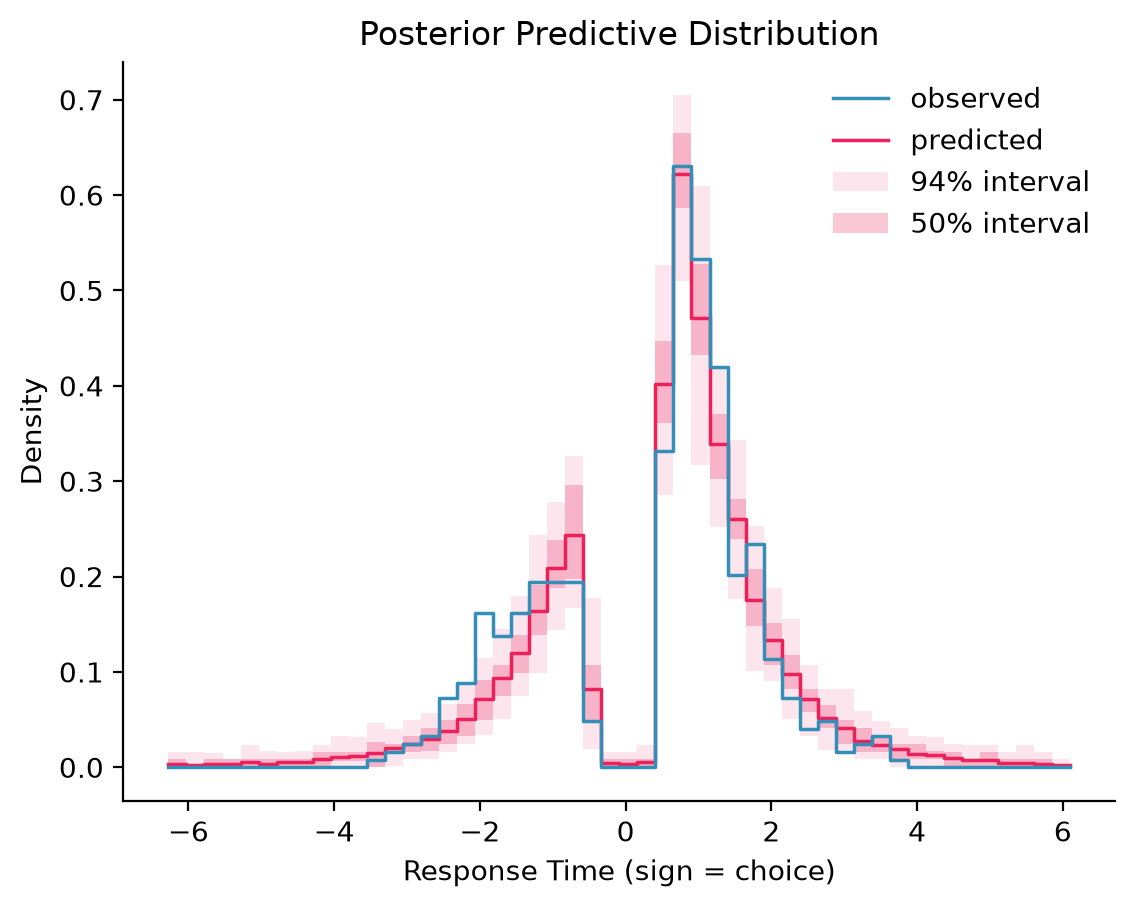

In [2]:
model.plot_predictive();

## `uncertainty="samples"` — the model-cartoon idiom

Every retained posterior draw as a translucent curve under an opaque mean.
More honest about multimodality; noisier at facet scale.

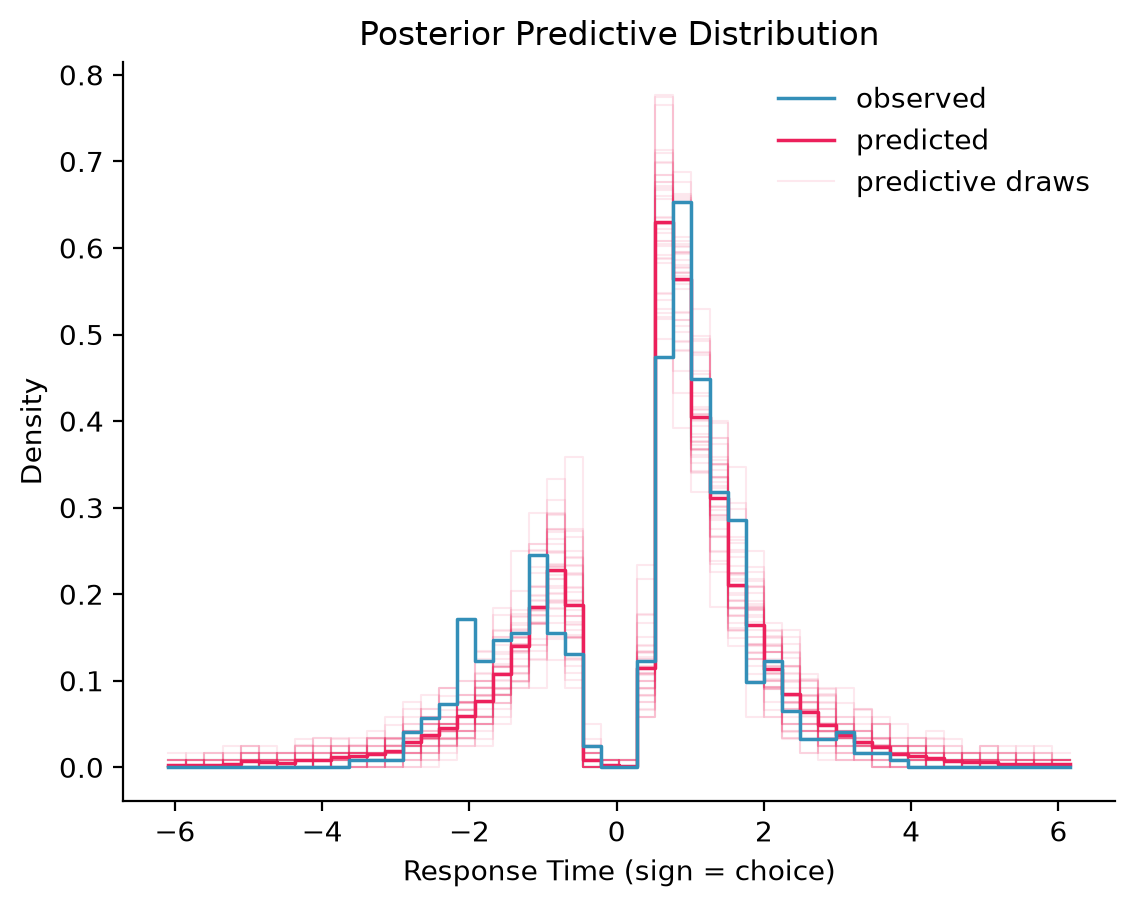

In [3]:
model.plot_predictive(uncertainty="samples");

## `uncertainty="both"`

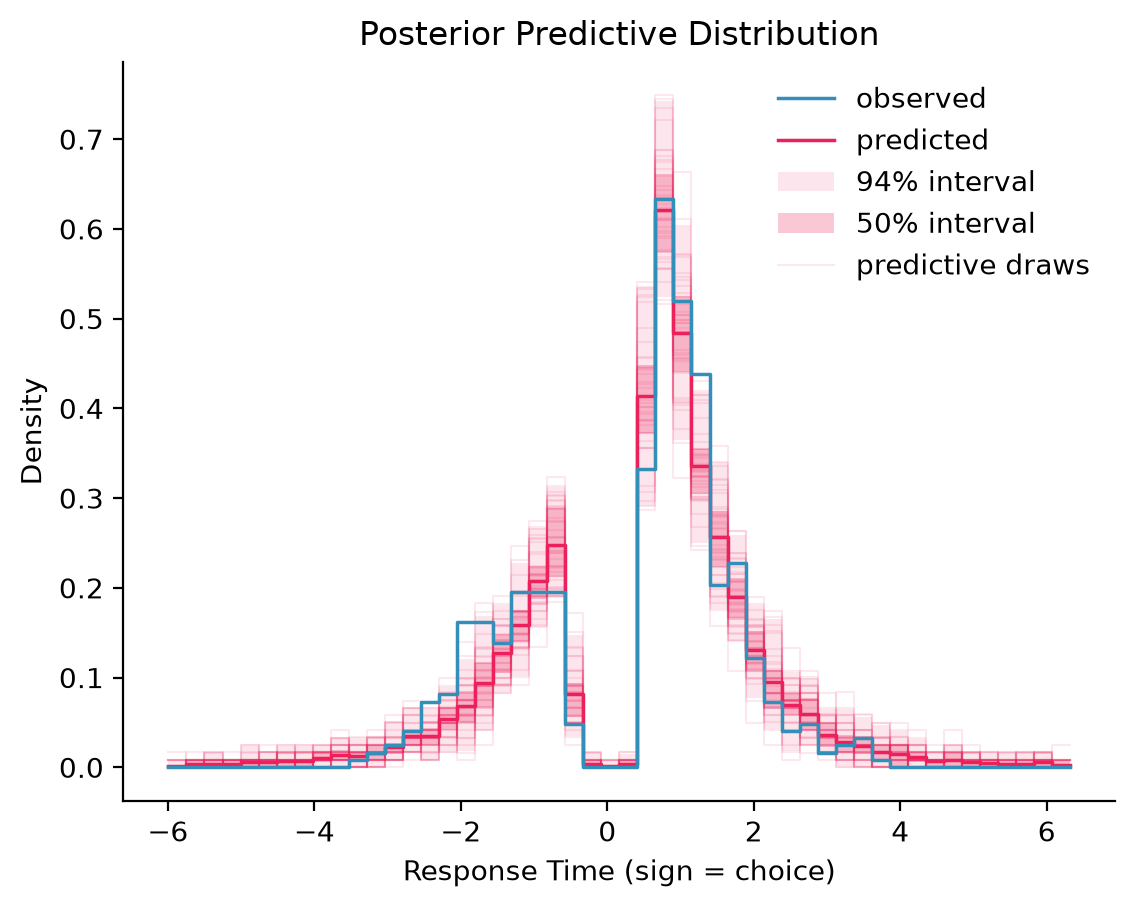

In [4]:
model.plot_predictive(uncertainty="both");

## Custom graded bands

`hdi=` takes a list, one entry per band — masses, `"90%"` strings, or
explicit quantile tuples.

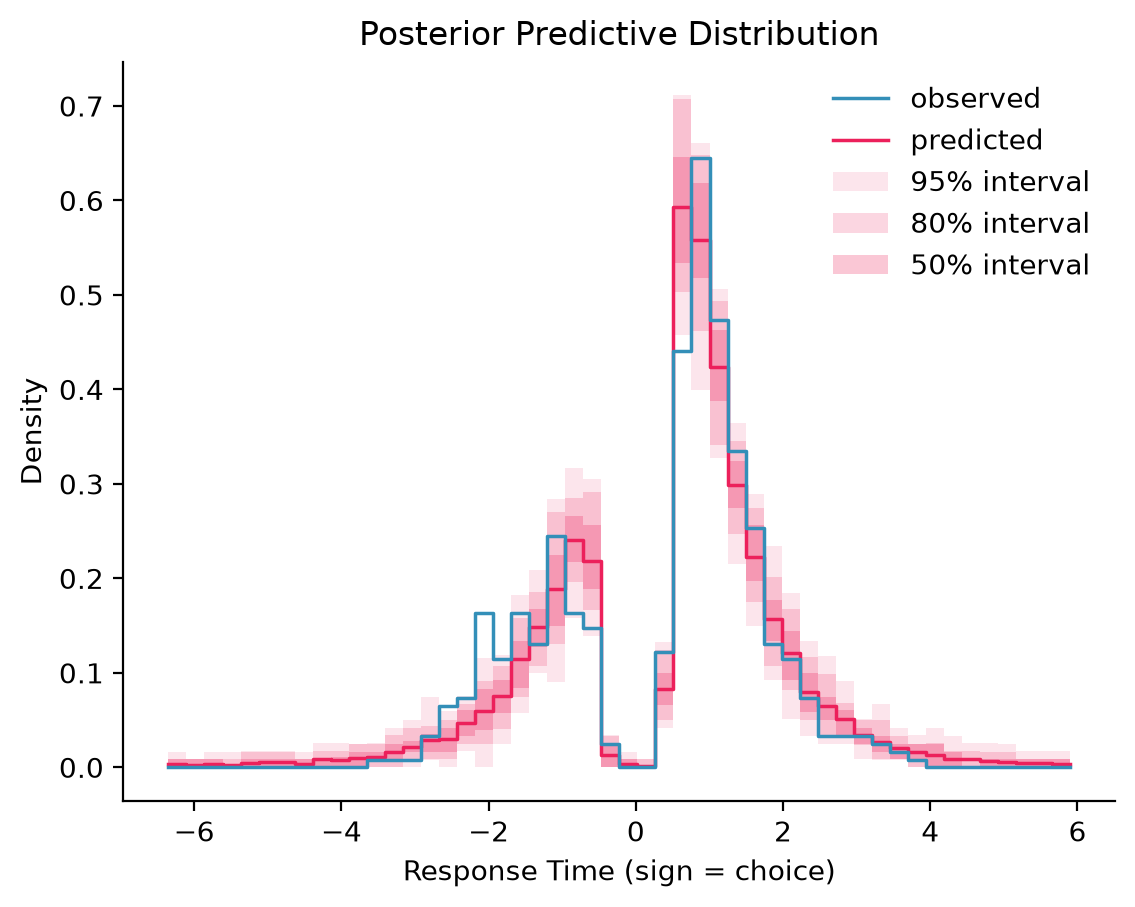

In [5]:
model.plot_predictive(hdi=[0.5, 0.8, 0.95]);

## KDE rendering

`kind="kde"` swaps the binned histogram for Gaussian kernel density
estimates, evaluated per posterior draw on a shared grid — the mean, bands,
and sample curves work identically. On the signed-RT axis the KDE is fit
**separately per choice side**, weighted by response proportion, so no
density is smoothed across the gap at zero. Note the inherent tradeoff:
kernels still smooth *toward* zero on each side, so `kind="hist"` remains
the more faithful view right at the non-decision-time gap. `bw_method=`
tunes the bandwidth (scipy's Scott rule by default).

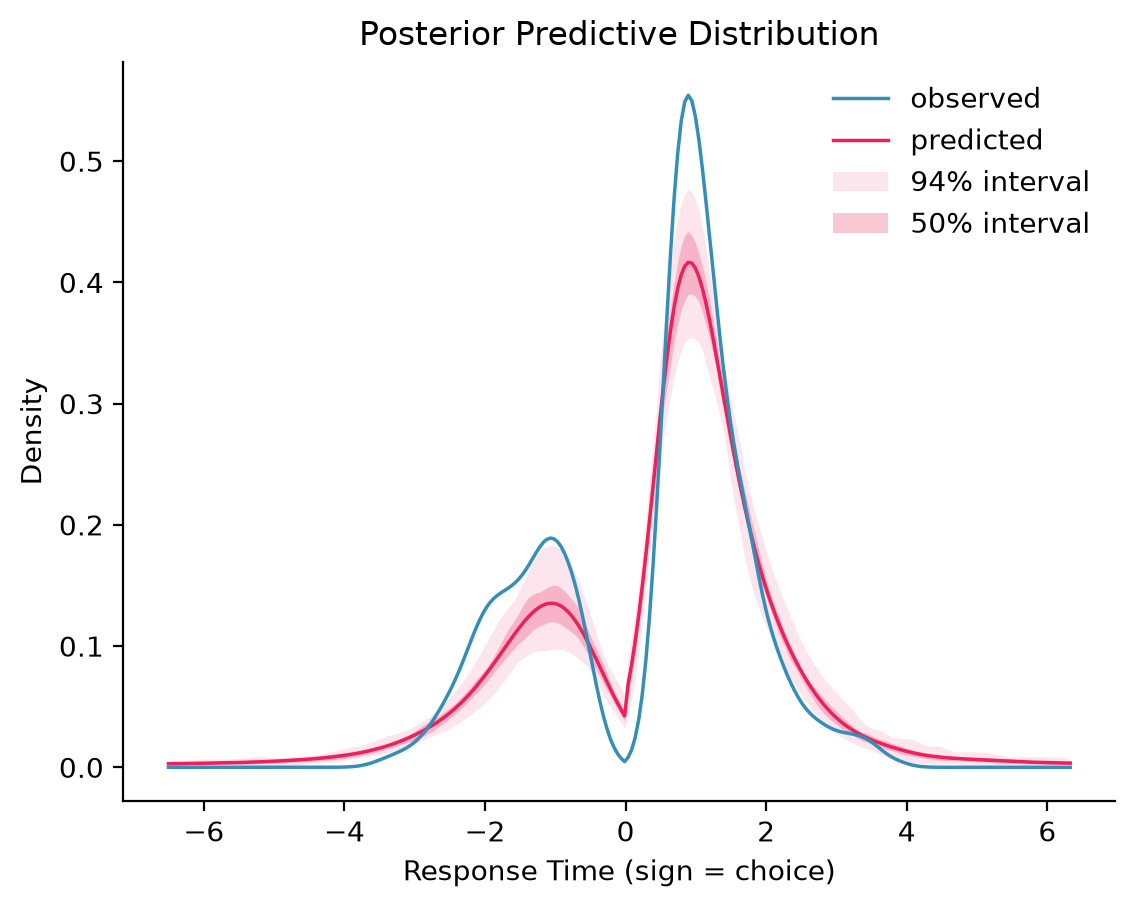

In [6]:
model.plot_predictive(kind="kde");

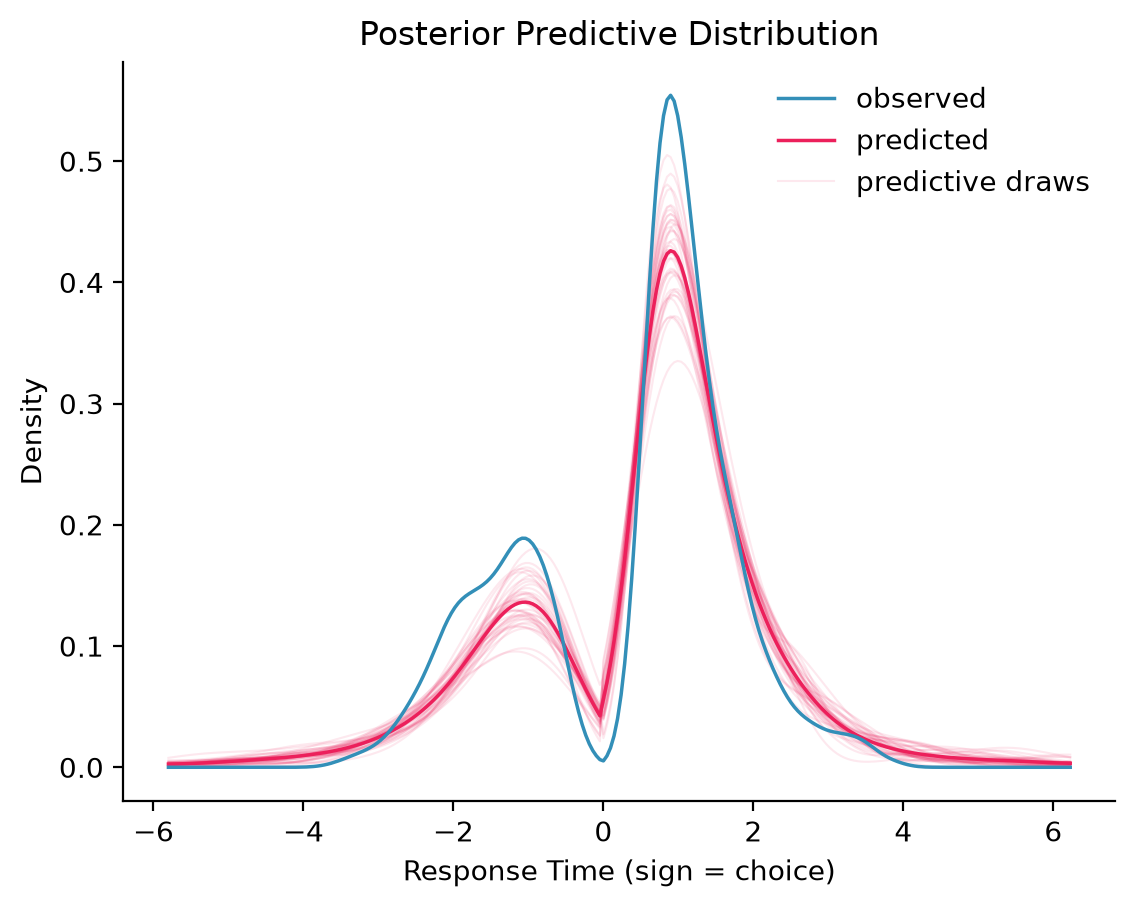

In [7]:
model.plot_predictive(kind="kde", uncertainty="samples");

## The classic line-plot look

`step=False` restores the frequency-polygon rendering the plot used before —
a connected line through the bin densities — now drawn through the bin
*centers* (the old version anchored at left bin edges, shifting every curve
by half a bin) and fully composable with bands and sample curves. Together
with the step default and `kind="kde"`, this rounds out the three renderings:
step histogram, frequency polygon, and kernel density.

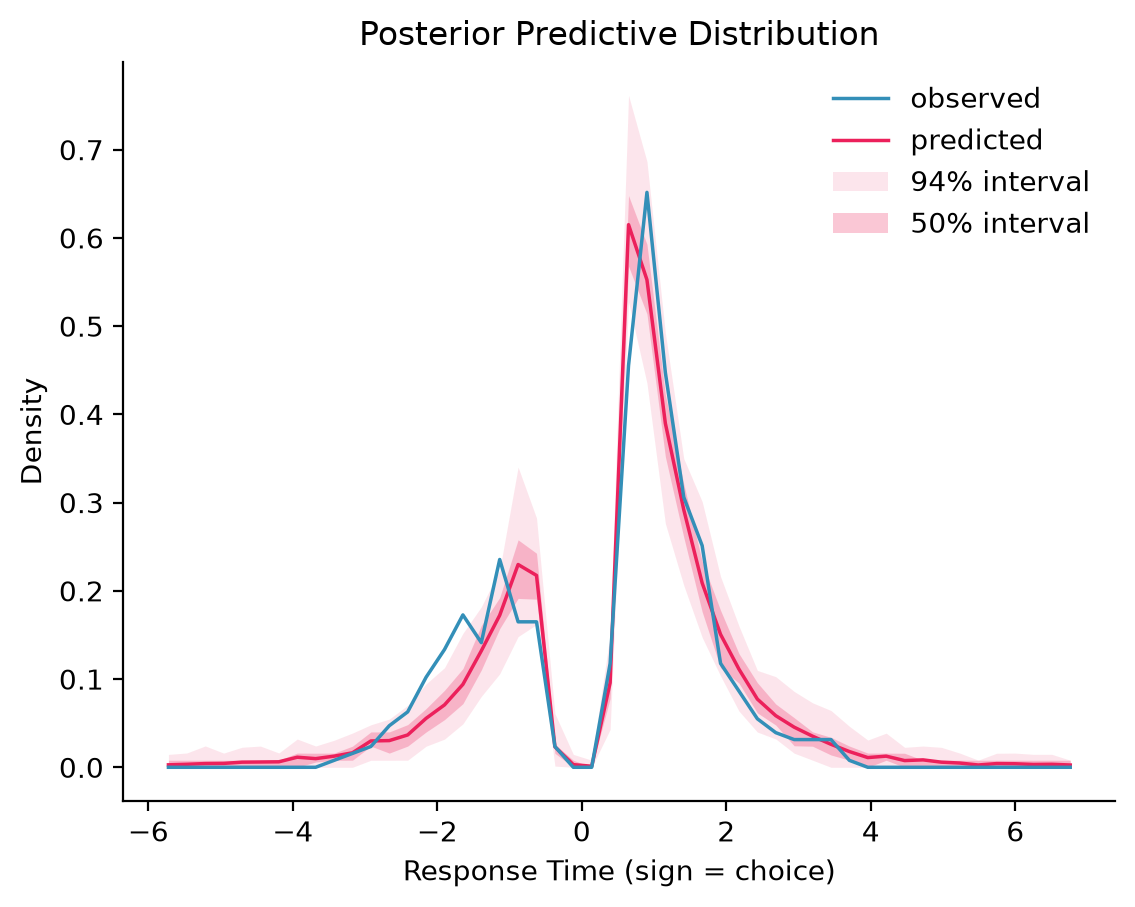

In [8]:
model.plot_predictive(step=False);

## Mean only

`uncertainty=None` draws just the predictive mean against the observed
data — the behavior of earlier HSSM versions.

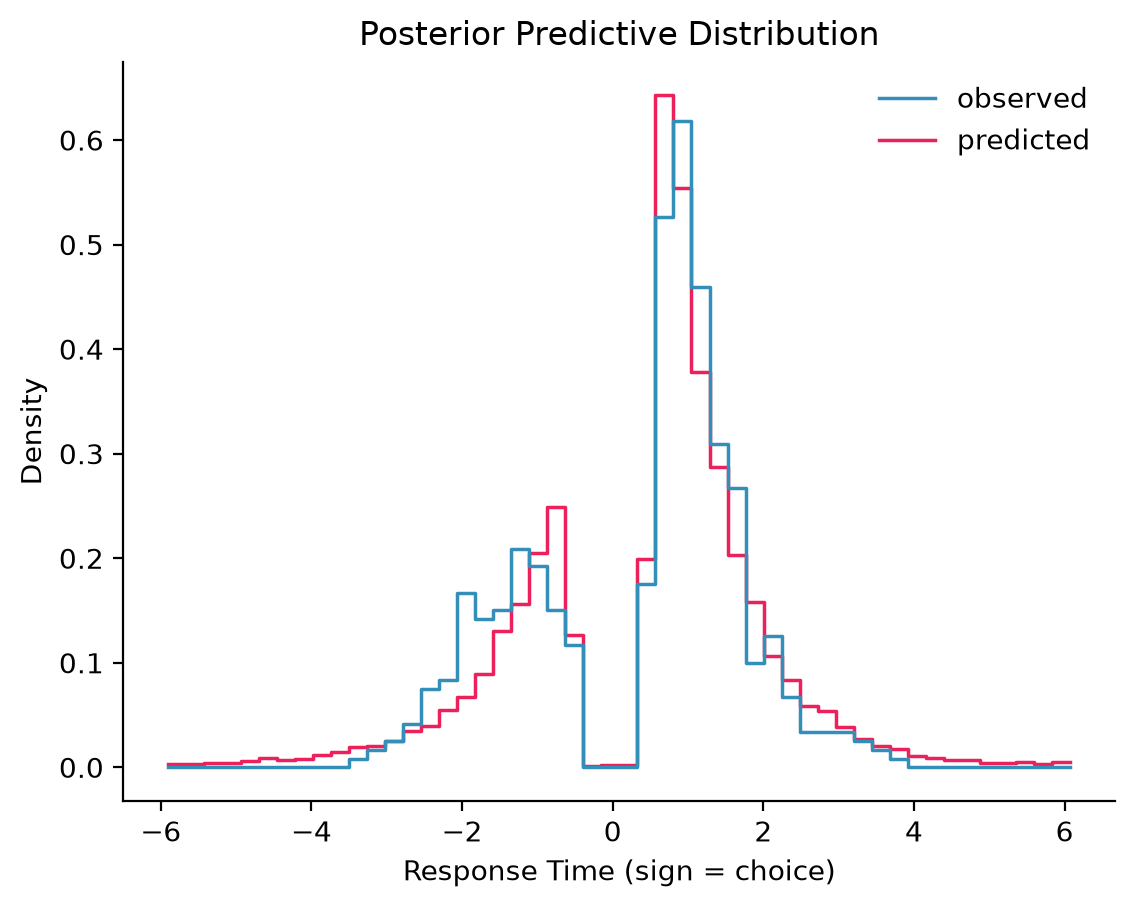

In [9]:
model.plot_predictive(uncertainty=None);

## Facets — the workhorse view

Bands propagate to grids unchanged; the legend is grid-level.

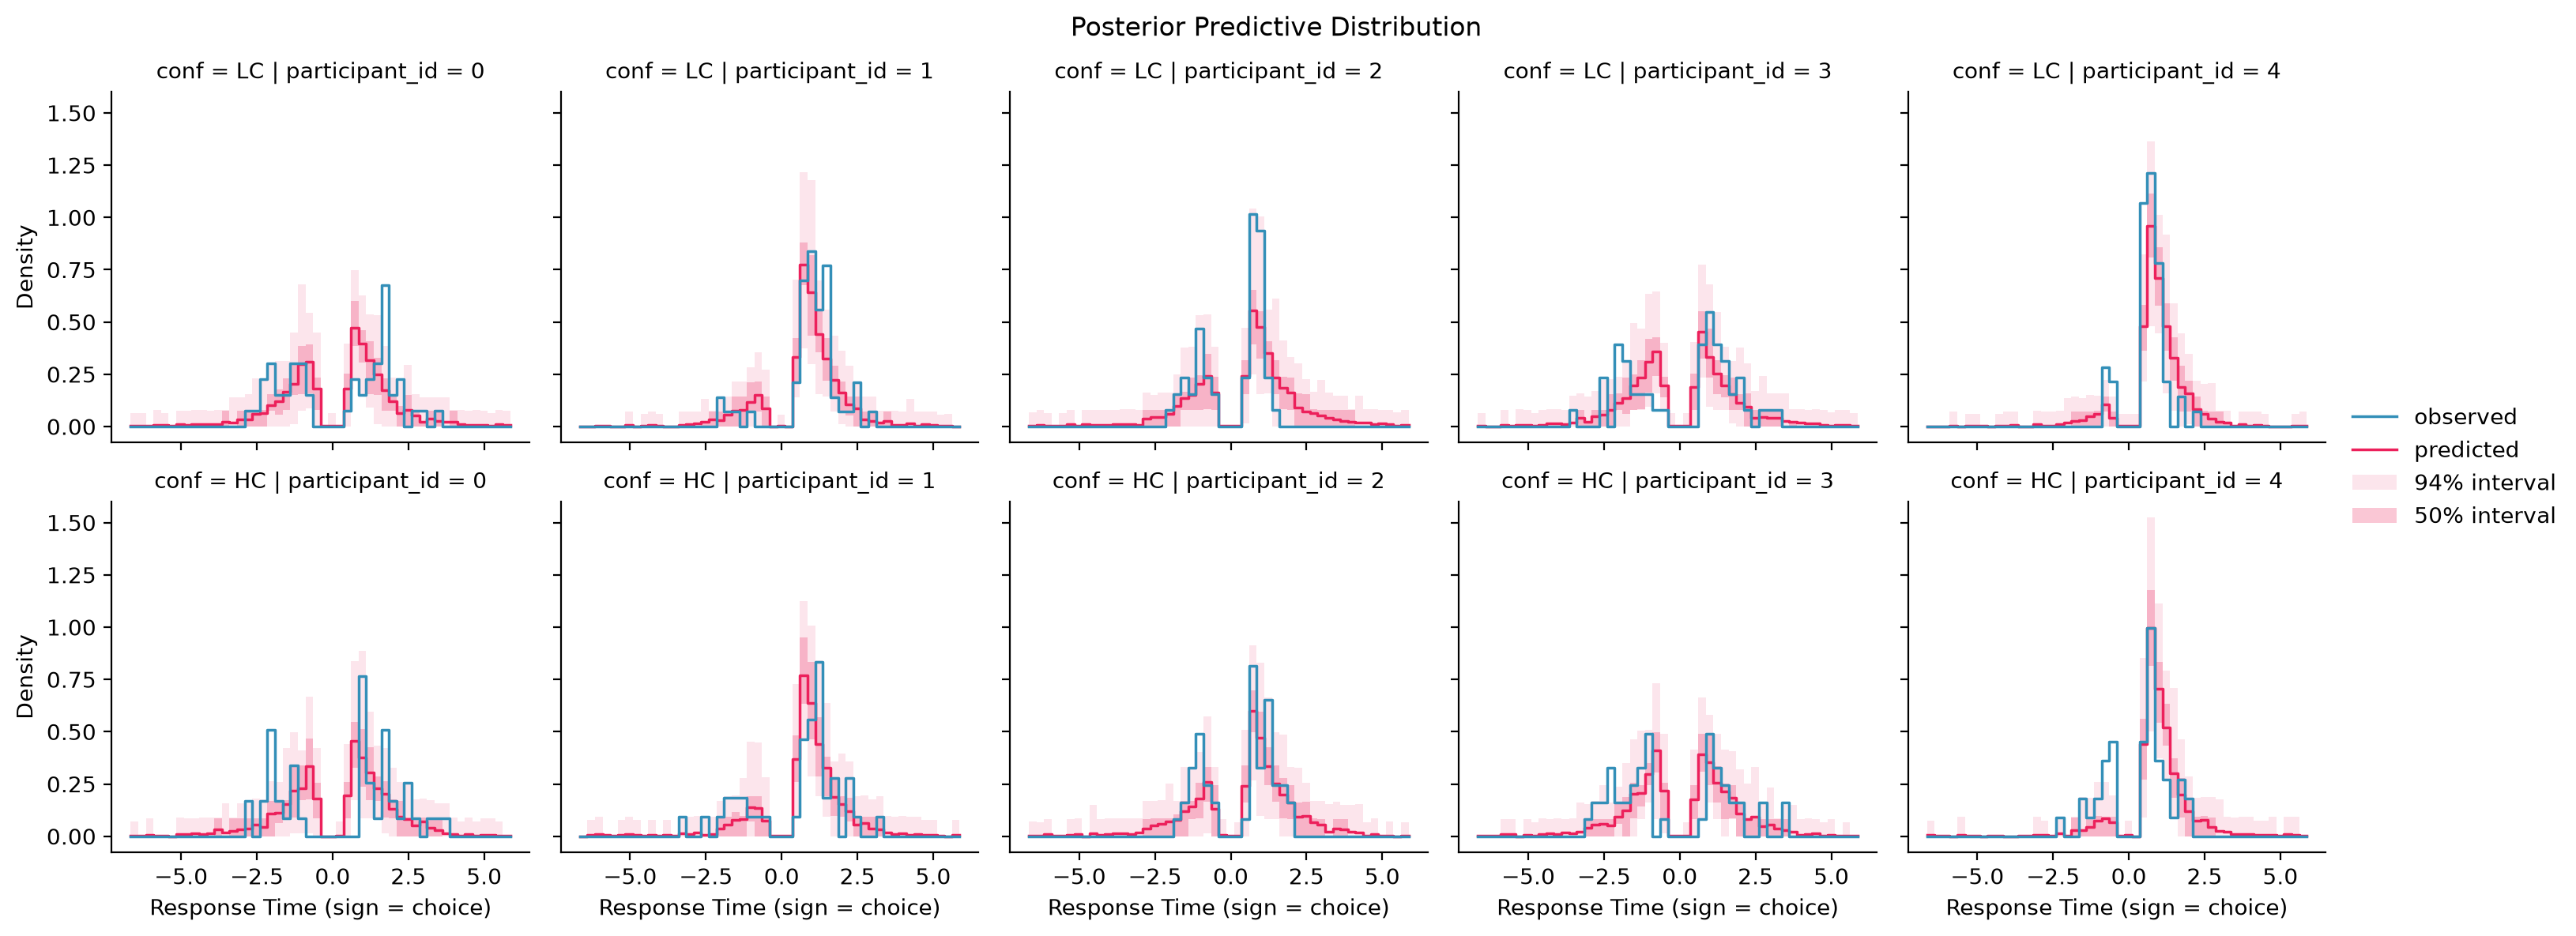

In [10]:
model.plot_predictive(col="participant_id", row="conf");

## Styling knobs

Per-source colors (dict now genuinely supported), band opacity, mean opacity.

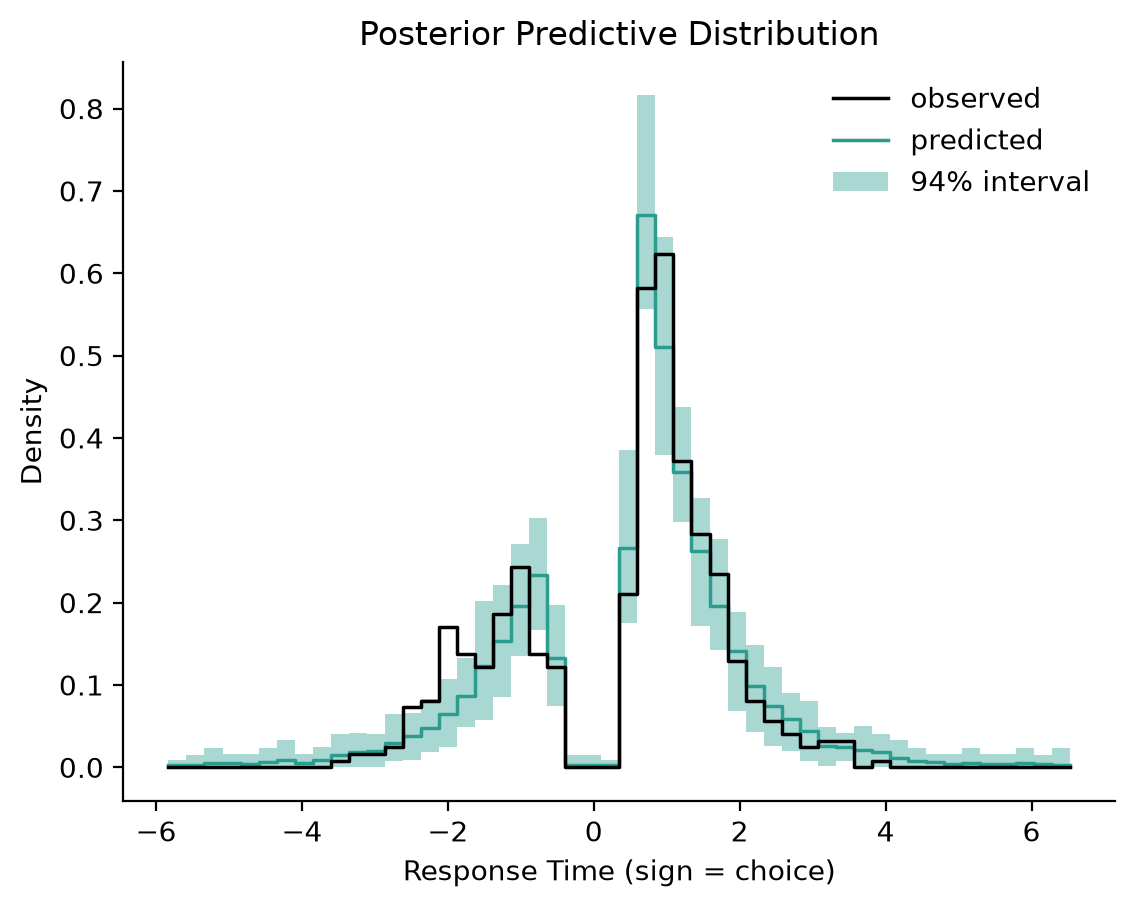

In [11]:
model.plot_predictive(
    colors={"predicted": "#2a9d8f", "observed": "black"},
    alpha_uncertainty=0.4,
    hdi=[0.94],
);

## Legacy spellings still work

`hdi=0.9`, `hdi="90%"`, and quantile tuples `hdi=(0.05, 0.95)` behave as
before (single band); prior-predictive titles itself correctly now.

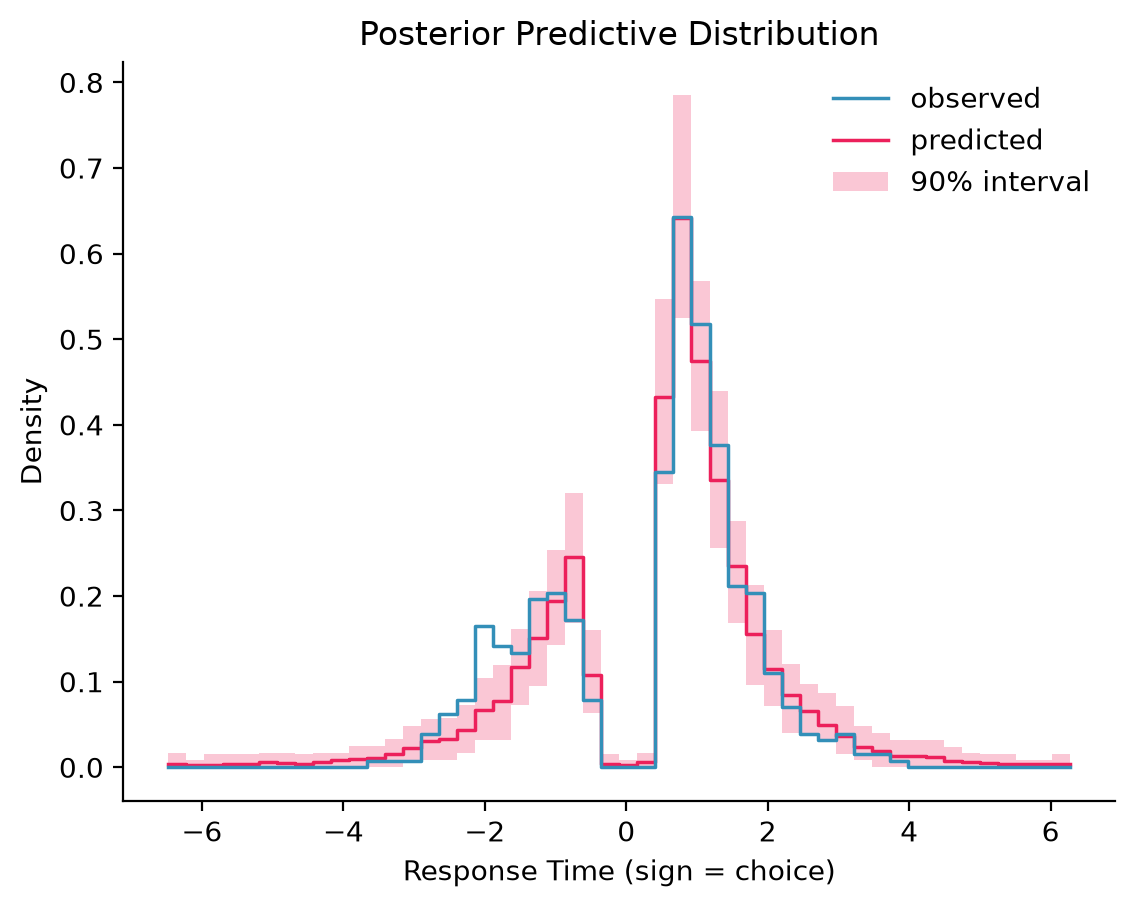

In [12]:
model.plot_predictive(hdi=(0.05, 0.95));